# Comparing PySIPS Priors: Base and Size-Calibrated Variants

This notebook compares the main prior distributions in `pysips.priors`, along with
their size-calibrated variants:

| Prior | Class | Description | Reference
|---|---|---|---|
| **Uniform** | `ImproperUniformPrior` | Improper uniform — assigns log P = 0 to every expression | Bomarito and Leser (2026) |
| **BMS** | `BMSPrior` | Bayesian Machine Scientist; scores by weighted operator counts | Guimera et al. (2020) |
| **Katz** | `KatzPrior` | Katz back-off n-gram language model on operator trees; n=2 | Bartlett et al. (2024) |
| **Size-cal Uniform** | `SizeCalibratedPrior(base_prior=None, ...)` | Uniform reweighted to match the corpus size distribution | This repo |
| **Size-cal BMS** | `SizeCalibratedPrior(base_prior=BMSPrior(...), ...)` | BMS reweighted to match the corpus size distribution | This repo |
| **Size-cal Katz** | `SizeCalibratedPrior(base_prior=KatzPrior(...), ...)` | Katz reweighted to match the corpus size distribution | This repo |

**Sections**
1. Construct the priors
2. Log-prior comparison table on a few hand-picked expressions
3. Distribution comparison on randomly-generated expressions (histograms and 2D histograms)
4. Corpus-conditioned Katz priors
5. Prior samples vs corpus statistics

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from sympy import sympify

from bingo.expressions.agraph import AGraphExpression
from bingo.expressions import ComponentGenerator, AGraphGenerator
from bingo.expressions.agraph.pyagraph import (
    ADDITION, SUBTRACTION, MULTIPLICATION, DIVISION,
    SIN, COS, EXPONENTIAL, LOGARITHM, POWER,
    IS_ARITY_2_ARRAY, IS_TERMINAL_ARRAY,
)

from pysips.priors import (
    ImproperUniformPrior,
    BMSPrior,
    load_bms_weights,
    KatzPrior,
    SizeCalibratedPrior,
    fit_size_calibrated_prior,
    load_corpus,
    load_katz_model,
)

rng = np.random.default_rng(42)
np.random.seed(42)

## 1. Construct the priors

We compare three base priors and three size-calibrated priors, all tied to the
**benchmark corpus**.

- The **BMS** prior loads pre-fit weights via `load_bms_weights("benchmark")`.
- The **Katz** prior loads `default_katz_n2_benchmark.json` via `load_katz_model(n=2, corpus="benchmark")`.
- The three **size-calibrated** priors are fit on the fly for this notebook's
  `x_dim=2` and operator set, using `fit_size_calibrated_prior()`.
- The **Uniform** prior is a thin wrapper: `logpdf` always returns 0.

In [2]:
X_DIM = 2  # number of input variables used throughout
COMPARE_OPERATORS = [
    ADDITION, SUBTRACTION, MULTIPLICATION, DIVISION,
    SIN, COS, EXPONENTIAL, LOGARITHM, POWER,
]
CAL_MAX_SIZE = 64
CAL_SHAPES_PER_SIZE = 250

# --- Uniform ---
# ImproperUniformPrior needs a generator; we don't use sampling here,
# so pass a minimal placeholder. logpdf always returns 0.
def _dummy_gen():
    """Never called for scoring — only needed if rvs() is used."""
    raise NotImplementedError

uniform_prior = ImproperUniformPrior(_dummy_gen)

def uniform_logpdf_single(_ag):
    return 0.0

# --- BMS (benchmark-fit defaults) ---
bms_weights, bms_sq_weights = load_bms_weights("benchmark")
bms_prior = BMSPrior(
    weights=bms_weights,
    squared_weights=bms_sq_weights,
    x_dim=X_DIM,
)

# --- Katz n=2 (benchmark default) ---
katz_model = load_katz_model(n=2, corpus="benchmark")
katz_prior = KatzPrior(katz_model, x_dim=X_DIM)

benchmark_corpus = load_corpus("benchmark")

uniform_cal_data = fit_size_calibrated_prior(
    base_prior=None,
    corpus=benchmark_corpus,
    x_dim=X_DIM,
    operators=COMPARE_OPERATORS,
    max_size=CAL_MAX_SIZE,
    n_shapes_per_size=CAL_SHAPES_PER_SIZE,
    random_state=42,
)
bms_cal_data = fit_size_calibrated_prior(
    base_prior=bms_prior,
    corpus=benchmark_corpus,
    x_dim=X_DIM,
    operators=COMPARE_OPERATORS,
    max_size=CAL_MAX_SIZE,
    n_shapes_per_size=CAL_SHAPES_PER_SIZE,
    random_state=42,
)
katz_cal_data = fit_size_calibrated_prior(
    base_prior=katz_prior,
    corpus=benchmark_corpus,
    x_dim=X_DIM,
    operators=COMPARE_OPERATORS,
    max_size=CAL_MAX_SIZE,
    n_shapes_per_size=CAL_SHAPES_PER_SIZE,
    random_state=42,
)

size_cal_uniform_prior = SizeCalibratedPrior(
    base_prior=None,
    log_z_k=uniform_cal_data["log_z_k"],
    corpus_log_hist=uniform_cal_data["corpus_log_hist"],
)
size_cal_bms_prior = SizeCalibratedPrior(
    base_prior=bms_prior,
    log_z_k=bms_cal_data["log_z_k"],
    corpus_log_hist=bms_cal_data["corpus_log_hist"],
)
size_cal_katz_prior = SizeCalibratedPrior(
    base_prior=katz_prior,
    log_z_k=katz_cal_data["log_z_k"],
    corpus_log_hist=katz_cal_data["corpus_log_hist"],
)

print("Priors constructed.")
print(f"  Katz model n={katz_prior.n}, vocab size={len(katz_model.left_model.vocabulary)}")
print(f"  Size calibration max size={CAL_MAX_SIZE}, shapes/size={CAL_SHAPES_PER_SIZE}")

Priors constructed.
  Katz model n=2, vocab size=22
  Size calibration max size=64, shapes/size=250


## 2. Log-prior comparison on example expressions

We score a few hand-picked expressions that differ in structure and complexity:

| Expression | Description |
|---|---|
| `X_0 + X_1` | Linear sum — simple, two terminals |
| `sin(X_0) + sin(X_1)` | Sum of sines — motivating example from Bartlett et al. |
| `exp(-X_0**2) * X_1` | Gaussian-like product — deeper tree |

In [3]:
EXAMPLE_EXPRS = [
    ("X_0 + X_1",             "simple linear sum"),
    ("sin(X_0) + sin(X_1)",   "sum of sines"),
    ("exp(-X_0**2) * X_1",    "Gaussian-like product"),
    ("X_0",         "variable only"),
    ("1.0*X0*X3*X4/X2", "more complex expression"),
]

priors_map = [
    ("Uniform",          uniform_logpdf_single),
    ("BMS",              bms_prior._logpdf_single),
    ("Katz n=2",         katz_prior._logpdf_single),
    ("Size-cal Uniform", size_cal_uniform_prior._logpdf_single),
    ("Size-cal BMS",     size_cal_bms_prior._logpdf_single),
    ("Size-cal Katz",    size_cal_katz_prior._logpdf_single),
]

# Header
col_w = 28
header = f"{'Expression':<{col_w}}" + "".join(f"{name:>12}" for name, _ in priors_map)
print(header)
print("-" * len(header))

for expr_str, desc in EXAMPLE_EXPRS:
    ag = AGraphExpression(equation=expr_str)
    scores = [fn(ag) for _, fn in priors_map]
    row = f"{expr_str:<{col_w}}" + "".join(f"{s:>12.3f}" for s in scores)
    print(row)

print()
print("(Higher values = more probable under that prior; size calibration only changes cross-size weighting.)")

Expression                       Uniform         BMS    Katz n=2Size-cal UniformSize-cal BMSSize-cal Katz
---------------------------------------------------------------------------------------------------------
X_0 + X_1                          0.000       0.740      -5.115      -8.391      -8.064      -7.622
sin(X_0) + sin(X_1)                0.000      -2.798     -18.039     -11.324     -14.743     -18.761
exp(-X_0**2) * X_1                 0.000       2.435     -12.348     -15.250     -13.684     -12.306
X_0                                0.000      -0.000      -0.953      -7.901      -7.901      -7.579
1.0*X0*X3*X4/X2                    0.000       6.497     -10.857     -20.183     -14.831     -11.093

(Higher values = more probable under that prior; size calibration only changes cross-size weighting.)


### The paper's motivating example: nested vs sum-of-sines

Bartlett et al. argue that `sin(x₀)+sin(x₁)` should be *more probable* than `sin(sin(x₀+x₁))`
under a parent-conditioned prior (n ≥ 2), even though both have the same node counts.

In [4]:
nested    = AGraphExpression(equation="sin(sin(X0 + X1))")
sum_sines = AGraphExpression(equation="sin(X0) + sin(X1)")

print(f"{'Prior':<12}  {'sin(sin(x+y))':>18}  {'sin(x)+sin(y)':>18}  {'prefer sum?':>12}")
for name, fn in priors_map:
    a = fn(nested)
    b = fn(sum_sines)
    mark = "yes" if b > a else ("tie" if b == a else "NO")
    print(f"{name:<12}  {a:>18.4f}  {b:>18.4f}  {mark:>12}")

Prior              sin(sin(x+y))       sin(x)+sin(y)   prefer sum?
Uniform                   0.0000              0.0000           tie
BMS                      -2.7978             -2.7978           tie
Katz n=2                -20.2348            -18.0392           yes
Size-cal Uniform            -11.3239            -11.3239           tie
Size-cal BMS            -14.7428            -14.7428           tie
Size-cal Katz            -20.9567            -18.7611           yes


## 3. Distribution comparison on randomly-generated expressions

We generate **10000 unique** `AGraphExpression`s with DAG complexity < 16 using bingo's
standard `AGraphGenerator`, then score each expression under all six priors.

Operators: `{+, -, ×, ÷, sin, cos, exp, log, pow}` — a broad basis present in both the
BMS weight dictionary and the Katz vocabulary.

In [5]:
MAX_COMPLEXITY = 16   # DAG node count upper bound
N_TARGET       = 10000
OPERATORS      = COMPARE_OPERATORS

unique_exprs = set()
cg = ComponentGenerator(
    input_x_dimension=X_DIM,
    terminal_probability=0.1,
    constant_probability=0.3,
)
for op in OPERATORS:
    cg.add_operator(op)
generator = AGraphGenerator(MAX_COMPLEXITY*3//2, MAX_COMPLEXITY*3//2, cg)

attempts = 0
while len(unique_exprs) < N_TARGET and attempts < 100 * N_TARGET:
    ag = generator()
    attempts += 1
    if ag.complexity < MAX_COMPLEXITY:
        unique_exprs.add(ag)

agraphs = list(unique_exprs)[:N_TARGET]
complexities = np.array([ag.complexity for ag in agraphs])
print(f"Generated {len(agraphs)} unique expressions")
print(f"  DAG complexity: min={complexities.min()}, max={complexities.max()}, "
      f"mean={complexities.mean():.2f}")

Generated 10000 unique expressions
  DAG complexity: min=1, max=15, mean=7.20


In [6]:
logp_uniform          = np.zeros(len(agraphs))
logp_bms              = np.array([bms_prior._logpdf_single(ag) for ag in agraphs])
logp_katz             = np.array([katz_prior._logpdf_single(ag) for ag in agraphs])
logp_size_cal_uniform = np.array([size_cal_uniform_prior._logpdf_single(ag) for ag in agraphs])
logp_size_cal_bms     = np.array([size_cal_bms_prior._logpdf_single(ag) for ag in agraphs])
logp_size_cal_katz    = np.array([size_cal_katz_prior._logpdf_single(ag) for ag in agraphs])

scores = {
    "Uniform": logp_uniform,
    "BMS": logp_bms,
    "Katz n=2": logp_katz,
    "Size-cal Uniform": logp_size_cal_uniform,
    "Size-cal BMS": logp_size_cal_bms,
    "Size-cal Katz": logp_size_cal_katz,
}

print("Summary statistics (log P):")
print(f"{'Prior':<12}  {'mean':>10}  {'std':>10}  {'min':>10}  {'max':>10}  {'finite':>8}")
for name, lp in scores.items():
    fin = lp[np.isfinite(lp)]
    print(f"{name:<12}  {fin.mean():>10.3f}  {fin.std():>10.3f}  "
          f"{fin.min():>10.3f}  {fin.max():>10.3f}  {len(fin):>5}/{len(lp)}")

Summary statistics (log P):
Prior               mean         std         min         max    finite
Uniform            0.000       0.000       0.000       0.000  10000/10000
BMS               -2.423       3.603     -39.148      10.437  10000/10000
Katz n=2         -36.312      21.953    -254.647      -0.953  10000/10000
Size-cal Uniform     -24.745      14.398    -110.963      -6.889   9935/10000
Size-cal BMS     -28.001      15.966    -142.177      -5.966   9935/10000
Size-cal Katz     -35.600      20.417    -229.223      -3.178   9935/10000


### 3a. Marginal histograms

Each panel shows the distribution of log P values under one prior, evaluated on the same
set of random expressions. The calibrated priors redistribute mass across expression sizes,
while preserving within-size preferences inherited from their base priors.

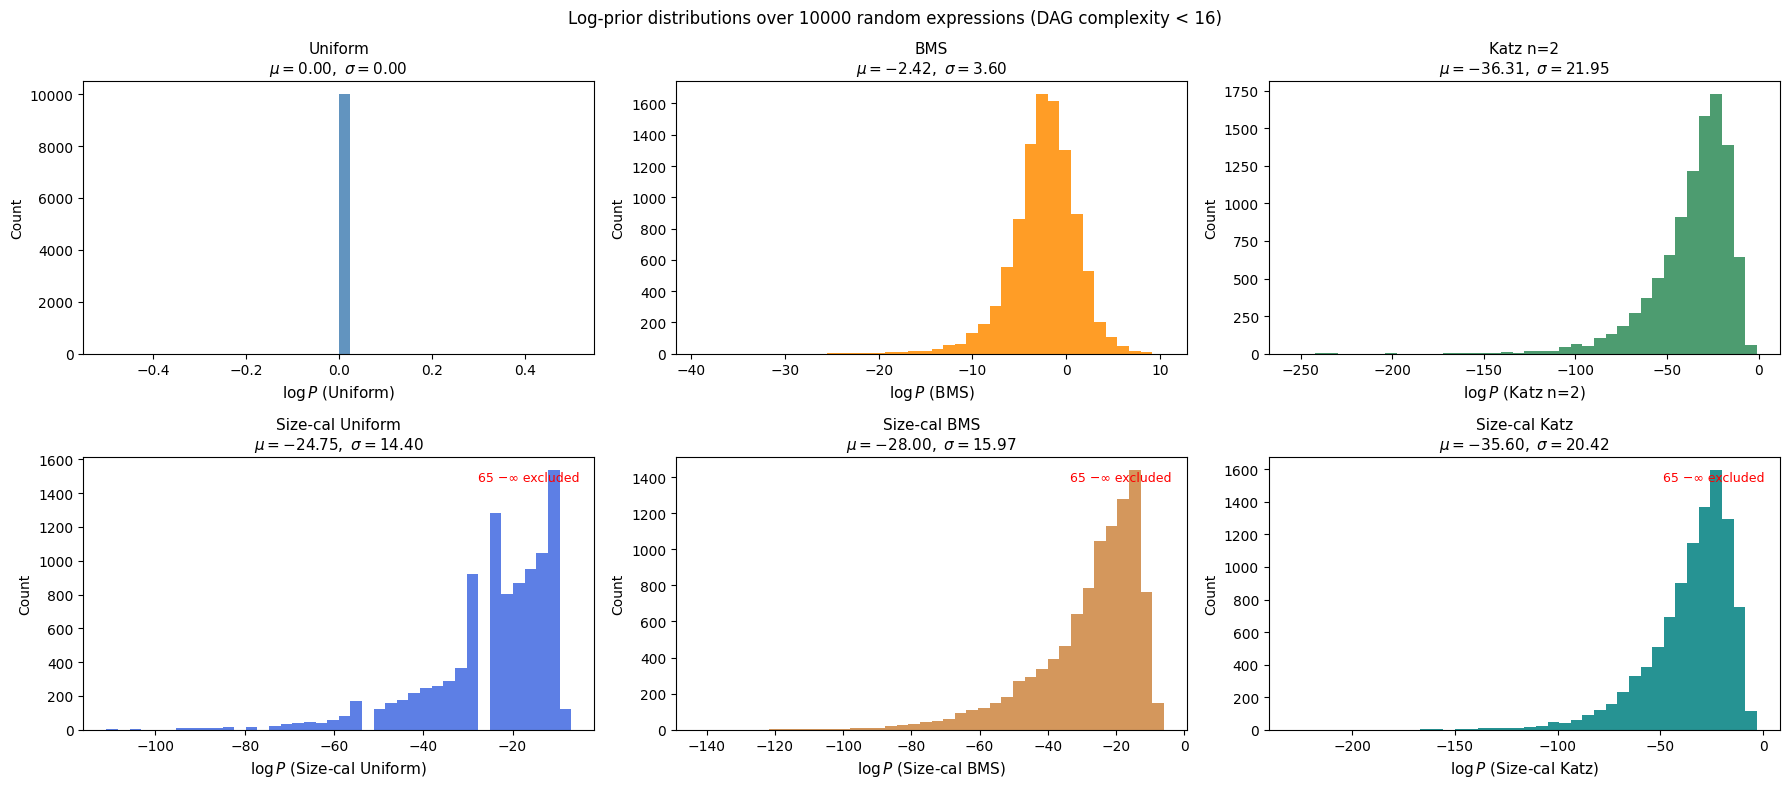

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharey=False)
axes = axes.ravel()
colors = {
    "Uniform": "steelblue",
    "BMS": "darkorange",
    "Katz n=2": "seagreen",
    "Size-cal Uniform": "royalblue",
    "Size-cal BMS": "peru",
    "Size-cal Katz": "teal",
}

for ax, (name, lp) in zip(axes, scores.items()):
    fin = lp[np.isfinite(lp)]
    ax.hist(fin, bins=40, color=colors[name], edgecolor="none", alpha=0.85)
    ax.set_xlabel(rf"$\log P$ ({name})", fontsize=11)
    ax.set_ylabel("Count", fontsize=10)
    ax.set_title(f"{name}\n"
                 rf"$\mu={fin.mean():.2f},\ \sigma={fin.std():.2f}$",
                 fontsize=11)
    n_inf = int((~np.isfinite(lp)).sum())
    if n_inf:
        ax.annotate(f"{n_inf} −∞ excluded", xy=(0.97, 0.95), xycoords="axes fraction",
                    ha="right", va="top", fontsize=9, color="red")

fig.suptitle(f"Log-prior distributions over {len(agraphs)} random expressions"
             f" (DAG complexity < {MAX_COMPLEXITY})", fontsize=12)
plt.tight_layout()
plt.show()

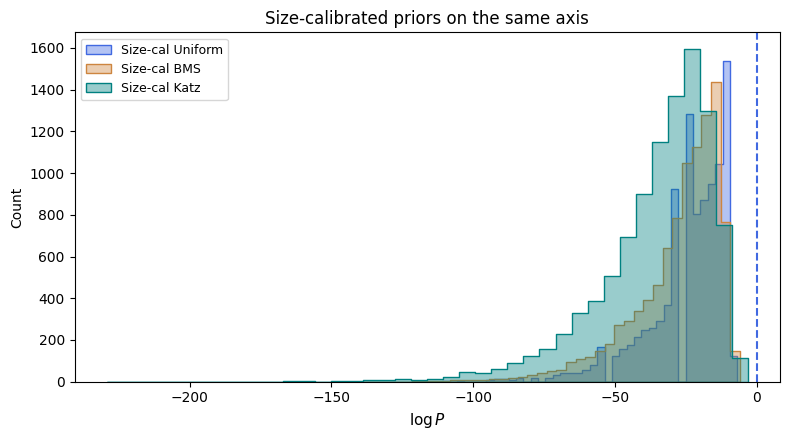

In [8]:
import seaborn as sns

overlay_data = [
    ("Size-cal Uniform", scores["Size-cal Uniform"]),
    ("Size-cal BMS", scores["Size-cal BMS"]),
    ("Size-cal Katz", scores["Size-cal Katz"]),
]

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, lp in overlay_data:
    fin = lp[np.isfinite(lp)]
    sns.histplot(
        fin,
        bins=40,
        stat="count",
        element="step",
        fill=True,
        alpha=0.4,
        color=colors[name],
        label=name,
        ax=ax,
    )

ax.axvline(0.0, color=colors["Size-cal Uniform"], linestyle="--", linewidth=1.5)
ax.set_xlabel(r"$\log P$", fontsize=11)
ax.set_ylabel("Count", fontsize=10)
ax.set_title("Size-calibrated priors on the same axis", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 3b. Pairwise 2D histograms

Each panel below compares either a base prior to its size-calibrated counterpart, or one
size-calibrated prior to another. A diagonal cloud indicates that the two priors rank
expressions similarly on the shared finite-support subset.

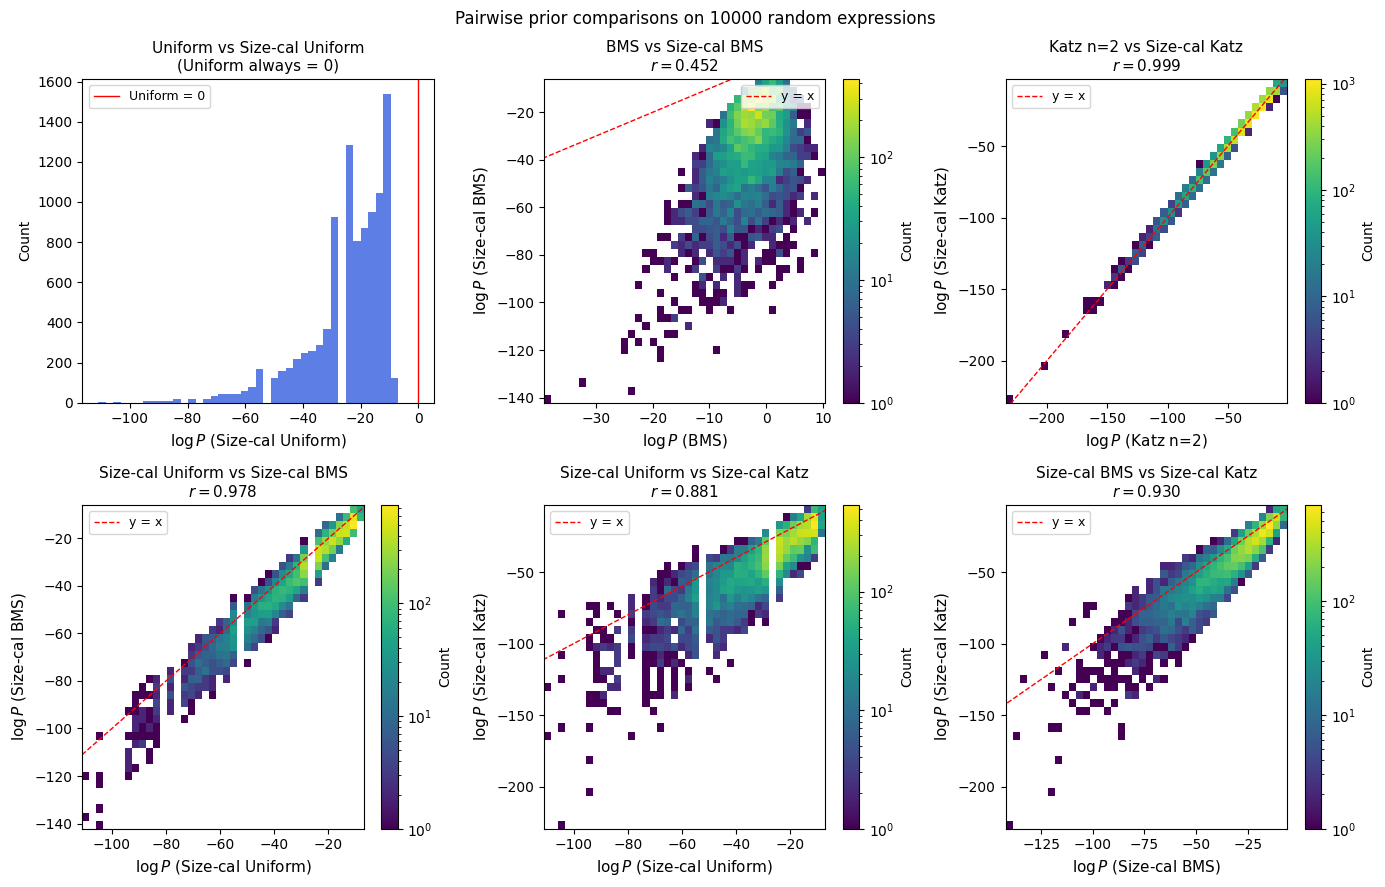

Pearson r(BMS, Size-cal BMS) on 9935 finite expressions: 0.4525
Pearson r(Katz n=2, Size-cal Katz) on 9935 finite expressions: 0.9991
Pearson r(Size-cal BMS, Size-cal Katz) on 9935 finite expressions: 0.9305


In [9]:
pairs = [
    ("Uniform", "Size-cal Uniform"),
    ("BMS", "Size-cal BMS"),
    ("Katz n=2", "Size-cal Katz"),
    ("Size-cal Uniform", "Size-cal BMS"),
    ("Size-cal Uniform", "Size-cal Katz"),
    ("Size-cal BMS", "Size-cal Katz"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()

for ax, (nx, ny) in zip(axes, pairs):
    lx, ly = scores[nx], scores[ny]
    fin = np.isfinite(lx) & np.isfinite(ly)
    x, y = lx[fin], ly[fin]

    if nx == "Uniform":
        # Uniform is constant — show as a 1D histogram instead
        ax.hist(y, bins=40, color=colors[ny], alpha=0.85, edgecolor="none",
                orientation="vertical")
        ax.axvline(0, color="red", lw=1, label="Uniform = 0")
        ax.set_xlabel(rf"$\log P$ ({ny})", fontsize=11)
        ax.set_ylabel("Count", fontsize=10)
        ax.set_title(f"Uniform vs {ny}\n(Uniform always = 0)", fontsize=11)
        ax.legend(fontsize=9)
    else:
        h = ax.hist2d(x, y, bins=40, cmap="viridis", norm=LogNorm())
        plt.colorbar(h[3], ax=ax, label="Count")
        mn = min(x.min(), y.min())
        mx = max(x.max(), y.max())
        ax.plot([mn, mx], [mn, mx], "r--", lw=1, label="y = x")
        r = np.corrcoef(x, y)[0, 1]
        ax.set_xlabel(rf"$\log P$ ({nx})", fontsize=11)
        ax.set_ylabel(rf"$\log P$ ({ny})", fontsize=11)
        ax.set_title(f"{nx} vs {ny}\n" + rf"$r={r:.3f}$", fontsize=11)
        ax.legend(fontsize=9)

fig.suptitle(f"Pairwise prior comparisons on {len(agraphs)} random expressions", fontsize=12)
plt.tight_layout()
plt.show()

# Print Pearson r for non-trivial pairs
for nx, ny in [
    ("BMS", "Size-cal BMS"),
    ("Katz n=2", "Size-cal Katz"),
    ("Size-cal BMS", "Size-cal Katz"),
]:
    fin = np.isfinite(scores[nx]) & np.isfinite(scores[ny])
    r = np.corrcoef(scores[nx][fin], scores[ny][fin])[0, 1]
    print(f"Pearson r({nx}, {ny}) on {fin.sum()} finite expressions: {r:.4f}")

### 3c. Mean log-prior vs structural complexity

For each complexity value, we compute the **mean log P** over all expressions in the
random sample that have that complexity. This shows how the size-calibrated priors reshape
cross-size preferences relative to their base priors.

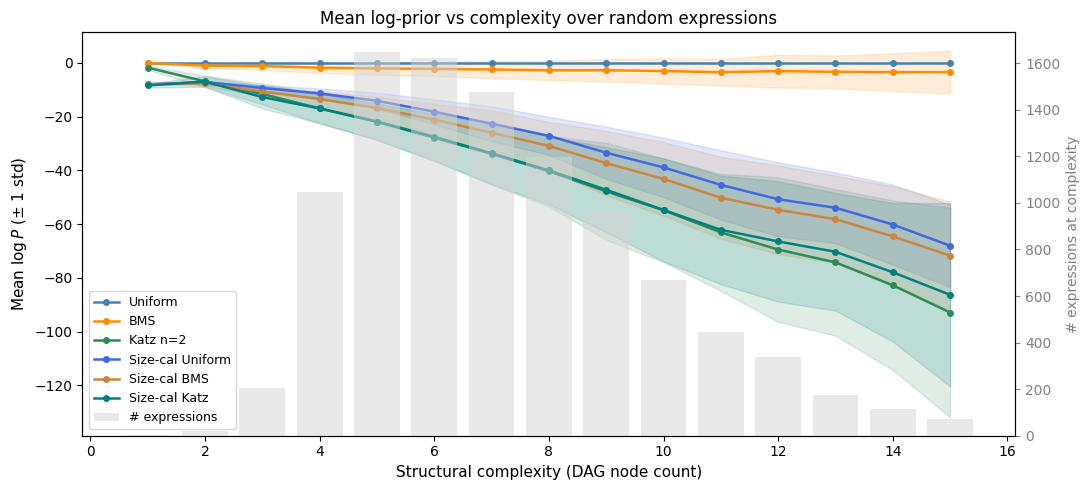

In [10]:
complexity_vals = np.array([ag.complexity for ag in agraphs])
unique_complexities = np.sort(np.unique(complexity_vals))

# For each prior, compute mean (and std) log P at each complexity level,
# skipping -inf values so they don't drag the mean down artificially.
mean_by_complexity = {}
std_by_complexity  = {}
for name, lp in scores.items():
    means, stds = [], []
    for c in unique_complexities:
        mask = (complexity_vals == c) & np.isfinite(lp)
        if mask.sum() > 0:
            means.append(lp[mask].mean())
            stds.append(lp[mask].std())
        else:
            means.append(np.nan)
            stds.append(np.nan)
    mean_by_complexity[name] = np.array(means)
    std_by_complexity[name]  = np.array(stds)

# Count expressions per complexity bin (for the secondary axis)
counts_per_complexity = np.array([(complexity_vals == c).sum() for c in unique_complexities])

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

prior_colors = {
    "Uniform": "steelblue",
    "BMS": "darkorange",
    "Katz n=2": "seagreen",
    "Size-cal Uniform": "royalblue",
    "Size-cal BMS": "peru",
    "Size-cal Katz": "teal",
}

for name, means in mean_by_complexity.items():
    stds = std_by_complexity[name]
    clr  = prior_colors[name]
    valid = ~np.isnan(means)
    ax1.plot(unique_complexities[valid], means[valid], marker="o", markersize=4,
             color=clr, label=name, linewidth=1.8)
    ax1.fill_between(unique_complexities[valid],
                     (means - stds)[valid], (means + stds)[valid],
                     color=clr, alpha=0.15)

ax2.bar(unique_complexities, counts_per_complexity, color="lightgrey",
        edgecolor="none", alpha=0.5, label="# expressions")
ax2.set_ylabel("# expressions at complexity", fontsize=10, color="grey")
ax2.tick_params(axis="y", colors="grey")

ax1.set_xlabel("Structural complexity (DAG node count)", fontsize=11)
ax1.set_ylabel(r"Mean $\log P$ (± 1 std)", fontsize=11)
ax1.set_title("Mean log-prior vs complexity over random expressions", fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="lower left")

plt.tight_layout()
plt.show()

### 3d. Mean log-prior vs tree complexity

Same as 3c, but the x-axis is **tree complexity** — the number of nodes in the full
tree expansion of the DAG (repeated sub-graphs counted multiple times). This is also the
default size notion used by `SizeCalibratedPrior`, so it is the most direct view of the
calibration effect.

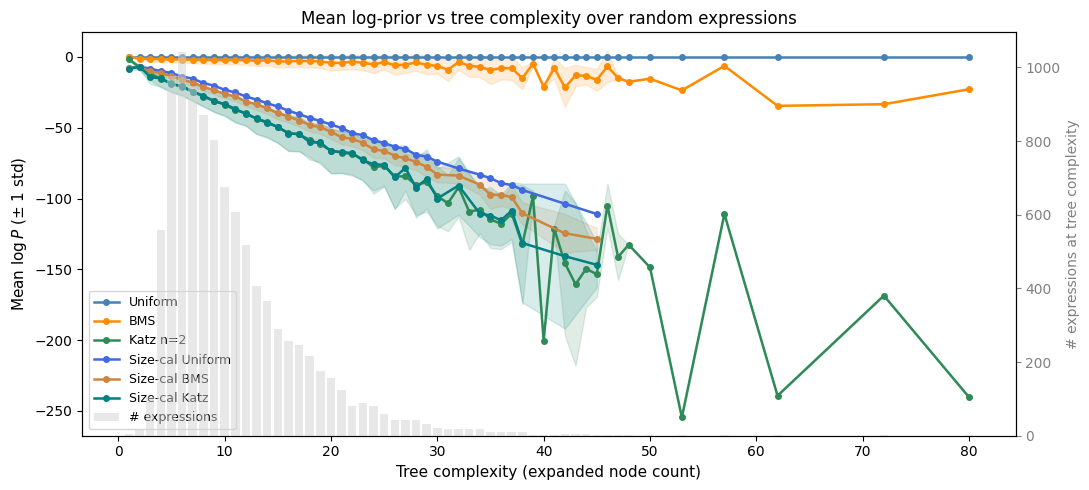

In [11]:
def tree_complexity(ag):
    """Total node count in the full tree expansion (repeated sub-graphs counted)."""
    return sum(ag.expression.get_operator_counts(tree=True, terminals="include").values())

tree_complexity_vals = np.array([tree_complexity(ag) for ag in agraphs])
unique_tree_complexities = np.sort(np.unique(tree_complexity_vals))

mean_by_tree = {}
std_by_tree  = {}
for name, lp in scores.items():
    means, stds = [], []
    for c in unique_tree_complexities:
        mask = (tree_complexity_vals == c) & np.isfinite(lp)
        if mask.sum() > 0:
            means.append(lp[mask].mean())
            stds.append(lp[mask].std())
        else:
            means.append(np.nan)
            stds.append(np.nan)
    mean_by_tree[name] = np.array(means)
    std_by_tree[name]  = np.array(stds)

counts_per_tree = np.array([(tree_complexity_vals == c).sum()
                            for c in unique_tree_complexities])

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

for name, means in mean_by_tree.items():
    stds  = std_by_tree[name]
    clr   = prior_colors[name]
    valid = ~np.isnan(means)
    ax1.plot(unique_tree_complexities[valid], means[valid], marker="o", markersize=4,
             color=clr, label=name, linewidth=1.8)
    ax1.fill_between(unique_tree_complexities[valid],
                     (means - stds)[valid], (means + stds)[valid],
                     color=clr, alpha=0.15)

ax2.bar(unique_tree_complexities, counts_per_tree, color="lightgrey",
        edgecolor="none", alpha=0.5, label="# expressions")
ax2.set_ylabel("# expressions at tree complexity", fontsize=10, color="grey")
ax2.tick_params(axis="y", colors="grey")

ax1.set_xlabel("Tree complexity (expanded node count)", fontsize=11)
ax1.set_ylabel(r"Mean $\log P$ (± 1 std)", fontsize=11)
ax1.set_title("Mean log-prior vs tree complexity over random expressions", fontsize=12)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc="lower left")

plt.tight_layout()
plt.show()

## 4. Corpus-conditioned Katz priors: "all_unique" vs "benchmark"

We fit three separate **Katz n=2** priors on different corpora:

| Prior | Training corpus | Description |
|---|---|---|
| **Katz (all)** | `"all_unique"` | All corpora combined, duplicates removed |
| **Katz (bench)** | `"benchmark"` | All unique equations minus the benchmark set |
| **Katz (wikipedia)** | `"wikipedia"` | Wikipedia copus with duplicates |

The 2D histogram below shows how the two priors score the same random expressions,
revealing whether removing the benchmark equations meaningfully shifts the prior.


Loading 'all_unique' corpus...
  912 unique equations
Loading 'benchmark' corpus...
  900 equations (benchmark eqs removed)
Loading 'wikipedia' corpus...
  4074 equations


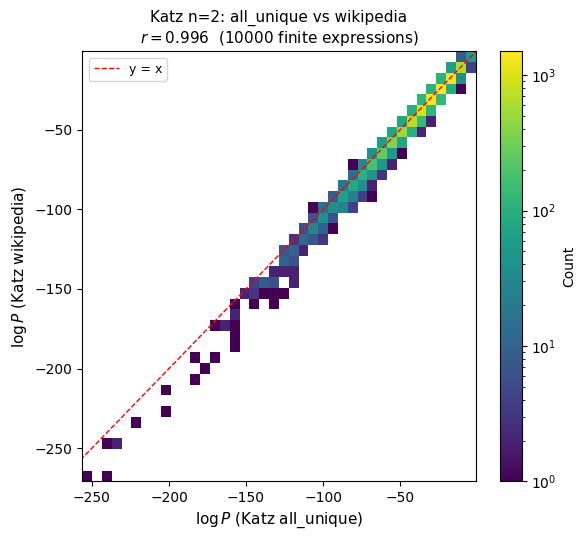


Pearson r = 0.9963 on 10000 finite expressions
Mean difference (wikipedia − all): -1.8935


In [12]:
from pysips.priors import load_corpus, fit_katz_prior

# --- Fit Katz n=2 on "all_unique" corpus ---
print("Loading 'all_unique' corpus...")
corpus_all = load_corpus("all_unique")
print(f"  {len(corpus_all)} unique equations")
katz_all = fit_katz_prior(corpus_all, n=2, x_dim=X_DIM)

# --- Fit Katz n=2 on "benchmark" corpus (all_unique minus benchmark eqs) ---
print("Loading 'benchmark' corpus...")
corpus_bench = load_corpus("benchmark")
print(f"  {len(corpus_bench)} equations (benchmark eqs removed)")
katz_bench = fit_katz_prior(corpus_bench, n=2, x_dim=X_DIM)

# --- Fit Katz n=2 on "wikipedia" corpus ---
print("Loading 'wikipedia' corpus...")
corpus_wiki = load_corpus("wikipedia")
print(f"  {len(corpus_wiki)} equations")
katz_wiki = fit_katz_prior(corpus_wiki, n=2, x_dim=X_DIM)

# --- Score the random expressions under both priors ---
logp_katz_all   = np.array([katz_all._logpdf_single(ag)   for ag in agraphs])
logp_katz_bench = np.array([katz_bench._logpdf_single(ag) for ag in agraphs])
logp_katz_wiki = np.array([katz_wiki._logpdf_single(ag) for ag in agraphs])

# --- 2D pairwise histogram ---
fin = np.isfinite(logp_katz_all) & np.isfinite(logp_katz_wiki)
x, y = logp_katz_all[fin], logp_katz_wiki[fin] #logp_katz_bench[fin]

fig, ax = plt.subplots(figsize=(6, 5.5))
h = ax.hist2d(x, y, bins=40, cmap="viridis", norm=LogNorm())
plt.colorbar(h[3], ax=ax, label="Count")

mn = min(x.min(), y.min())
mx = max(x.max(), y.max())
ax.plot([mn, mx], [mn, mx], "r--", lw=1, label="y = x")

r = np.corrcoef(x, y)[0, 1]
ax.set_xlabel(r"$\log P$ (Katz all_unique)", fontsize=11)
ax.set_ylabel(r"$\log P$ (Katz wikipedia)", fontsize=11)
ax.set_title(f"Katz n=2: all_unique vs wikipedia\n"
             rf"$r={r:.3f}$  ({fin.sum()} finite expressions)", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nPearson r = {r:.4f} on {fin.sum()} finite expressions")
print(f"Mean difference (wikipedia − all): {(y - x).mean():.4f}")


## 5. Prior samples vs corpus statistics

We draw samples from each prior using `rvs()` (SMC sampling) and compare
three statistics against the **benchmark corpus**:

1. **Operator frequencies** — relative frequency of each non-terminal operator
2. **Structural complexity** — `expression.complexity` (number of nodes in simplified DAG)
3. **Parametric complexity** — number of `CONSTANT` nodes in the expression tree

The size-calibrated priors reuse the benchmark-conditioned calibration data fit above.

In [13]:
from collections import Counter

from bingo.expressions.agraph.pyagraph import CONSTANT, VARIABLE, OPERATOR_NAMES
from bingo.expressions.agraph.evolvable import EvolvableExpression

def _unwrap(ag):
    """Unwrap EvolvableExpression to get the underlying AGraphExpression."""
    return ag.expression if isinstance(ag, EvolvableExpression) else ag

def get_operator_freq(expressions):
    """Return normalised operator frequency dict (non-terminals only)."""
    total = Counter()
    for ag in expressions:
        counts = _unwrap(ag).get_operator_counts(tree=True, terminals="exclude")
        total.update(counts)
    grand = sum(total.values())
    if grand == 0:
        return {}
    return {op: cnt / grand for op, cnt in total.items()}

def get_complexities(expressions):
    return np.array([_unwrap(ag).complexity for ag in expressions])

def count_constants(ag):
    """Count CONSTANT nodes in the tree traversal."""
    counts = _unwrap(ag).get_operator_counts(tree=True, terminals="include")
    return counts.get(CONSTANT, 0)

def get_constant_counts(expressions):
    return np.array([count_constants(ag) for ag in expressions])

def op_label(op_id):
    """Short human-readable label for an operator ID."""
    names = OPERATOR_NAMES.get(op_id, [str(op_id)])
    return names[-1] if len(names) > 1 else names[0]  # short alias

In [14]:
corpus_benchmark = load_corpus("benchmark")
print(f"Benchmark corpus: {len(corpus_benchmark)} equations")

corpus_op_freq   = get_operator_freq(corpus_benchmark)
corpus_complex   = get_complexities(corpus_benchmark)
corpus_n_consts  = get_constant_counts(corpus_benchmark)

print(f"  Complexity: mean={corpus_complex.mean():.1f}, "
      f"median={np.median(corpus_complex):.0f}, max={corpus_complex.max()}")
print(f"  Constants:  mean={corpus_n_consts.mean():.1f}, "
      f"median={np.median(corpus_n_consts):.0f}, max={corpus_n_consts.max()}")

Benchmark corpus: 900 equations
  Complexity: mean=10.5, median=9, max=59
  Constants:  mean=0.5, median=0, max=5


In [15]:
N_SAMPLES = 10000
SAMPLE_OPERATORS = [ADDITION, SUBTRACTION, MULTIPLICATION, DIVISION,
                    SIN, COS, EXPONENTIAL, LOGARITHM, POWER]

# Build samplable versions of each prior (with operators & x_dim set)
sampling_priors = {}

# Uniform — uses ImproperUniformPrior's rvs directly
uniform_sampler = ImproperUniformPrior(
    AGraphGenerator(MAX_COMPLEXITY * 3 // 2, MAX_COMPLEXITY * 3 // 2, cg)
)
sampling_priors["Uniform"] = uniform_sampler

size_cal_uniform_sampler = SizeCalibratedPrior(
    base_prior=None,
    log_z_k=uniform_cal_data["log_z_k"],
    corpus_log_hist=uniform_cal_data["corpus_log_hist"],
    x_dim=X_DIM,
    operators=SAMPLE_OPERATORS,
    max_complexity=MAX_COMPLEXITY * 3 // 2,
    num_mcmc_samples=10,
    target_ess=0.9,
)
sampling_priors["Size-cal Uniform"] = size_cal_uniform_sampler

# BMS
bms_sampler = BMSPrior(
    weights=bms_weights,
    squared_weights=bms_sq_weights,
    x_dim=X_DIM,
    operators=SAMPLE_OPERATORS,
    max_complexity=MAX_COMPLEXITY * 3 // 2,
    num_mcmc_samples=10,
    target_ess=0.9,
)
sampling_priors["BMS"] = bms_sampler

size_cal_bms_sampler = SizeCalibratedPrior(
    base_prior=bms_sampler,
    log_z_k=bms_cal_data["log_z_k"],
    corpus_log_hist=bms_cal_data["corpus_log_hist"],
    x_dim=X_DIM,
    operators=SAMPLE_OPERATORS,
    max_complexity=MAX_COMPLEXITY * 3 // 2,
    num_mcmc_samples=10,
    target_ess=0.9,
)
sampling_priors["Size-cal BMS"] = size_cal_bms_sampler

# Katz n=2
katz_sampler = KatzPrior(
    katz_model, normalize=False, x_dim=X_DIM,
    operators=SAMPLE_OPERATORS,
    max_complexity=MAX_COMPLEXITY * 3 // 2,
    num_mcmc_samples=10,
    target_ess=0.9,
)
sampling_priors["Katz n=2"] = katz_sampler

size_cal_katz_sampler = SizeCalibratedPrior(
    base_prior=katz_sampler,
    log_z_k=katz_cal_data["log_z_k"],
    corpus_log_hist=katz_cal_data["corpus_log_hist"],
    x_dim=X_DIM,
    operators=SAMPLE_OPERATORS,
    max_complexity=MAX_COMPLEXITY * 3 // 2,
    num_mcmc_samples=10,
    target_ess=0.9,
)
sampling_priors["Size-cal Katz"] = size_cal_katz_sampler

# Draw samples
samples = {}
for name, prior_obj in sampling_priors.items():
    print(f"Sampling {N_SAMPLES} from {name}...")
    raw = prior_obj.rvs(N_SAMPLES, random_state=42)
    samples[name] = [s for s in raw.ravel()]
    print(f"  Got {len(samples[name])} samples")

Sampling 10000 from Uniform...
  Got 10000 samples
Sampling 10000 from Size-cal Uniform...


[ mutation ratio: 0.8493: : 100.00%|██████████| phi: 1.00000/1.0 [01:59<00:00


  Got 10000 samples
Sampling 10000 from BMS...


[ mutation ratio: 0.9152: : 100.00%|██████████| phi: 1.00000/1.0 [02:26<00:00


  Got 10000 samples
Sampling 10000 from Size-cal BMS...


...

  Got 10000 samples
Sampling 10000 from Katz n=2...


[ mutation ratio: 0.6766: : 100.00%|██████████| phi: 1.00000/1.0 [02:46<00:00


  Got 10000 samples
Sampling 10000 from Size-cal Katz...


[ mutation ratio: 0.5565: : 100.00%|██████████| phi: 1.00000/1.0 [02:35<00:00

  Got 10000 samples


In [16]:
sample_op_freqs  = {name: get_operator_freq(samps) for name, samps in samples.items()}
sample_complexes = {name: get_complexities(samps)  for name, samps in samples.items()}
sample_n_consts  = {name: get_constant_counts(samps) for name, samps in samples.items()}

### 5a. Operator frequencies

Grouped bar chart comparing the relative frequency of each non-terminal operator
in the benchmark corpus vs samples drawn from each prior.

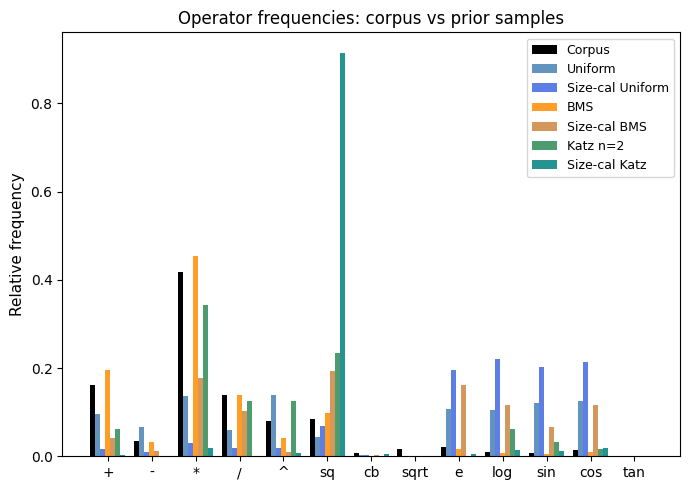

In [17]:
# Collect the union of all operators seen
all_ops = sorted(set(corpus_op_freq) | set().union(*sample_op_freqs.values()))
all_ops = [3, 4, 5, 6, 7, 9, 10, 11, 13, 14, 15, 16, 17]
op_labels = [op_label(op) for op in all_ops]

n_groups = len(all_ops)
n_sources = 1 + len(samples)  # corpus + each prior
bar_w = 0.8 / n_sources
x = np.arange(n_groups)

# fig, ax = plt.subplots(figsize=(14, 5))
fig, ax = plt.subplots(figsize=(7, 5))
source_colors = ["black", "steelblue", "royalblue", "darkorange", "peru", "seagreen", "teal"]
source_names  = ["Corpus"] + list(samples.keys())
source_freqs  = [corpus_op_freq] + list(sample_op_freqs.values())

for i, (sname, sfreq, clr) in enumerate(zip(source_names, source_freqs, source_colors)):
    vals = [sfreq.get(op, 0) for op in all_ops]
    ax.bar(x + i * bar_w, vals, bar_w, label=sname, color=clr, edgecolor="none",
           alpha=0.85 if sname != "Corpus" else 1.0)

ax.set_xticks(x + bar_w * (n_sources - 1) / 2)
ax.set_xticklabels(op_labels, fontsize=10)
ax.set_ylabel("Relative frequency", fontsize=11)
ax.set_title("Operator frequencies: corpus vs prior samples", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 5b. Structural complexity distribution

Overlaid histograms of DAG node count (`expression.complexity`) for the corpus
and each prior's samples.

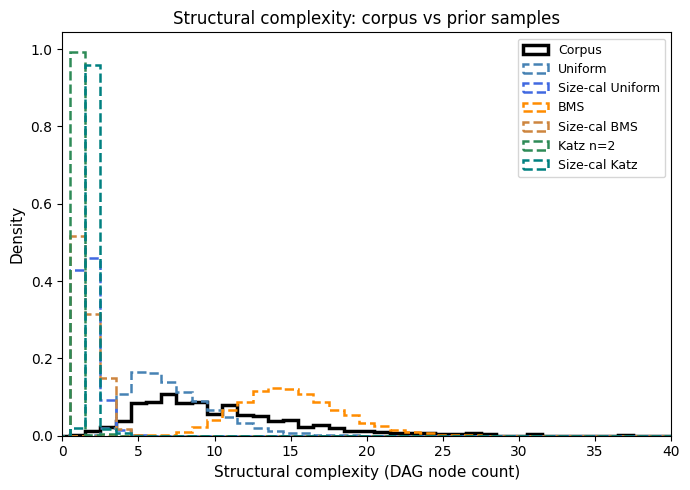

Source                mean    median       std     max
--------------------------------------------------------
Corpus                10.5         9       5.7      59
Uniform                7.3         7       2.8      21
Size-cal Uniform       1.7         2       0.7       5
BMS                   15.0        15       3.3      31
Size-cal BMS           1.7         1       0.8       5
Katz n=2               1.0         1       0.1       3
Size-cal Katz          2.0         2       0.3       6


In [18]:
# fig, ax = plt.subplots(figsize=(10, 5))
fig, ax = plt.subplots(figsize=(7, 5))
max_c = max(corpus_complex.max(), max(c.max() for c in sample_complexes.values()))
bins = np.arange(0, max_c + 2) - 0.5

ax.hist(corpus_complex, bins=bins, density=True, histtype="step", linewidth=2.5,
        color="black", label="Corpus")
for (name, comp), clr in zip(sample_complexes.items(), source_colors[1:]):
    ax.hist(comp, bins=bins, density=True, histtype="step", linewidth=1.8,
            color=clr, label=name, linestyle="--")

ax.set_xlabel("Structural complexity (DAG node count)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Structural complexity: corpus vs prior samples", fontsize=12)
ax.legend(fontsize=9)
plt.xlim(0, 40)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Source':<16}  {'mean':>8}  {'median':>8}  {'std':>8}  {'max':>6}")
print("-" * 56)
for sname, comp in [("Corpus", corpus_complex)] + list(sample_complexes.items()):
    print(f"{sname:<16}  {comp.mean():>8.1f}  {np.median(comp):>8.0f}  "
          f"{comp.std():>8.1f}  {comp.max():>6}")

### 5c. Parametric complexity (number of constants)

Overlaid histograms of the number of `CONSTANT` nodes in each expression's tree
traversal, comparing the corpus to prior samples.

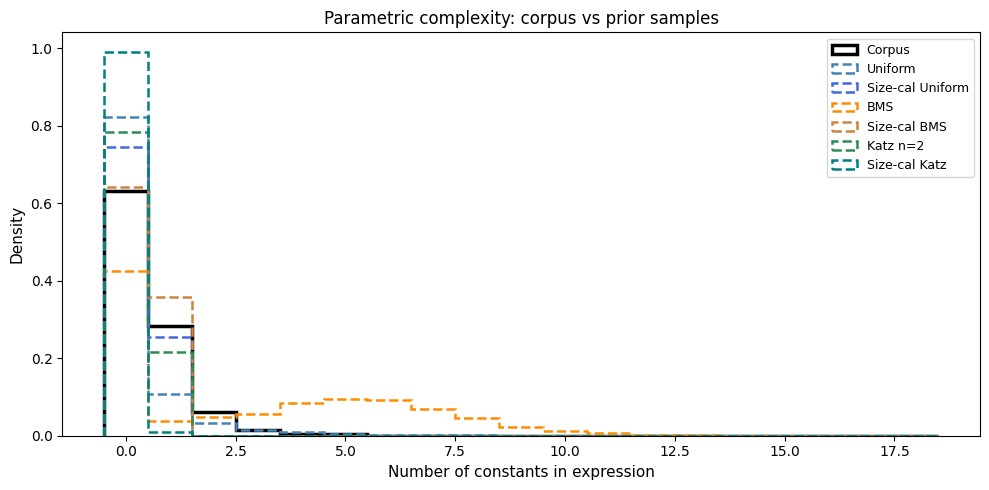

Source                mean    median       std     max
--------------------------------------------------------
Corpus                 0.5         0       0.8       5
Uniform                0.3         0       1.0      18
Size-cal Uniform       0.3         0       0.4       1
BMS                    3.0         2       3.1      15
Size-cal BMS           0.4         0       0.5       2
Katz n=2               0.2         0       0.4       1
Size-cal Katz          0.0         0       0.1       1


In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
max_const = max(corpus_n_consts.max(), max(c.max() for c in sample_n_consts.values()))
bins = np.arange(0, max_const + 2) - 0.5

ax.hist(corpus_n_consts, bins=bins, density=True, histtype="step", linewidth=2.5,
        color="black", label="Corpus")
for (name, nc), clr in zip(sample_n_consts.items(), source_colors[1:]):
    ax.hist(nc, bins=bins, density=True, histtype="step", linewidth=1.8,
            color=clr, label=name, linestyle="--")

ax.set_xlabel("Number of constants in expression", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Parametric complexity: corpus vs prior samples", fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Summary table
print(f"{'Source':<16}  {'mean':>8}  {'median':>8}  {'std':>8}  {'max':>6}")
print("-" * 56)
for sname, nc in [("Corpus", corpus_n_consts)] + list(sample_n_consts.items()):
    print(f"{sname:<16}  {nc.mean():>8.1f}  {np.median(nc):>8.0f}  "
          f"{nc.std():>8.1f}  {nc.max():>6}")